<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(NB_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
from tensorflow.keras import layers as KL

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)
from sklearn.linear_model import Ridge as RidgeMeta
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics         import accuracy_score, log_loss
from sklearn.model_selection import learning_curve

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 5: SETUP — restores state from Notebook 4              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Loads variables from the dill checkpoint saved by Notebook 4.

Restore mechanism:
    1. pip install dill (fast, already cached)
    2. Open checkpoint_2_to_3.pkl → dill.load() → globals().update()
       Makes all 336 Notebook 2 variables available in this session.
    3. Open checkpoint_4_to_5_keras.json → for each entry,
       keras.models.load_model(path) → globals()[name] = model
       Restores mlp_base_model (the baseline 2-layer MLP from Cell 19A).
"""

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_4_to_5"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 4 state loaded successfully.")
print("Continuing from Cell 27 below, unchanged.")

CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_4_to_5.pkl
  Variables restored    : 420
  Keras models restored : ['mlp_base_model', 'mlp_tuned', 'mlp_f']
  df_combined shape      : (119979, 51)

Notebook 4 state loaded successfully.
Continuing from Cell 27 below, unchanged.


CELL 26A — TRAINING/VALIDATION CURVES + MODEL COMPARISON BAR

Sweeping Decision Tree max_depth 1 → 20 ...
  Optimal depth (max val acc)  : 20  →  val acc  = 0.6781
  Optimal depth (min val loss) : 6  →  val loss = 0.5993
Computing learning curve (5-fold CV, 10 size steps) ...


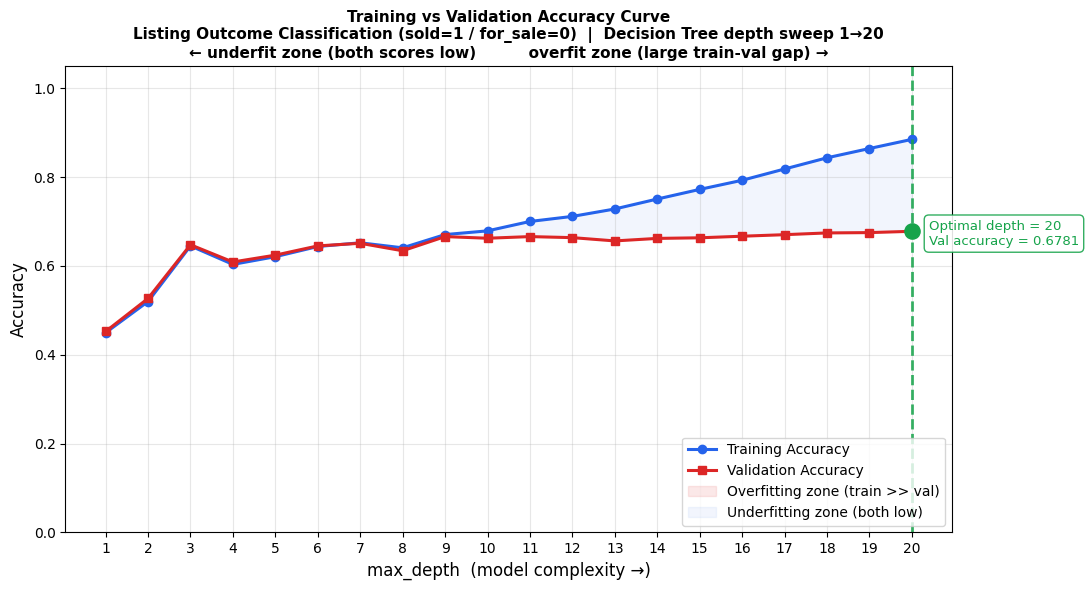


FIGURE 1 saved → /content/drive/MyDrive/RealEstate_TXNY/cell26A_accuracy_curve.png


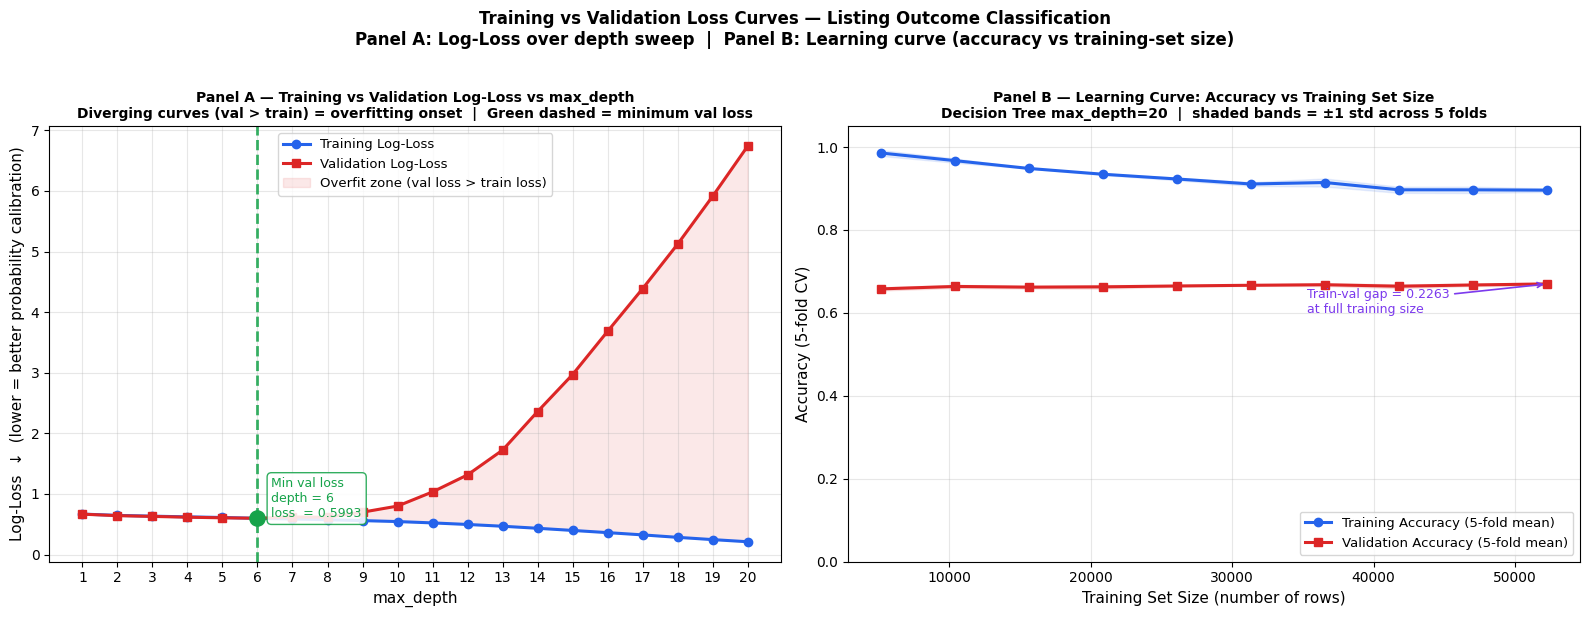

FIGURE 2 saved → /content/drive/MyDrive/RealEstate_TXNY/cell26A_loss_curve.png


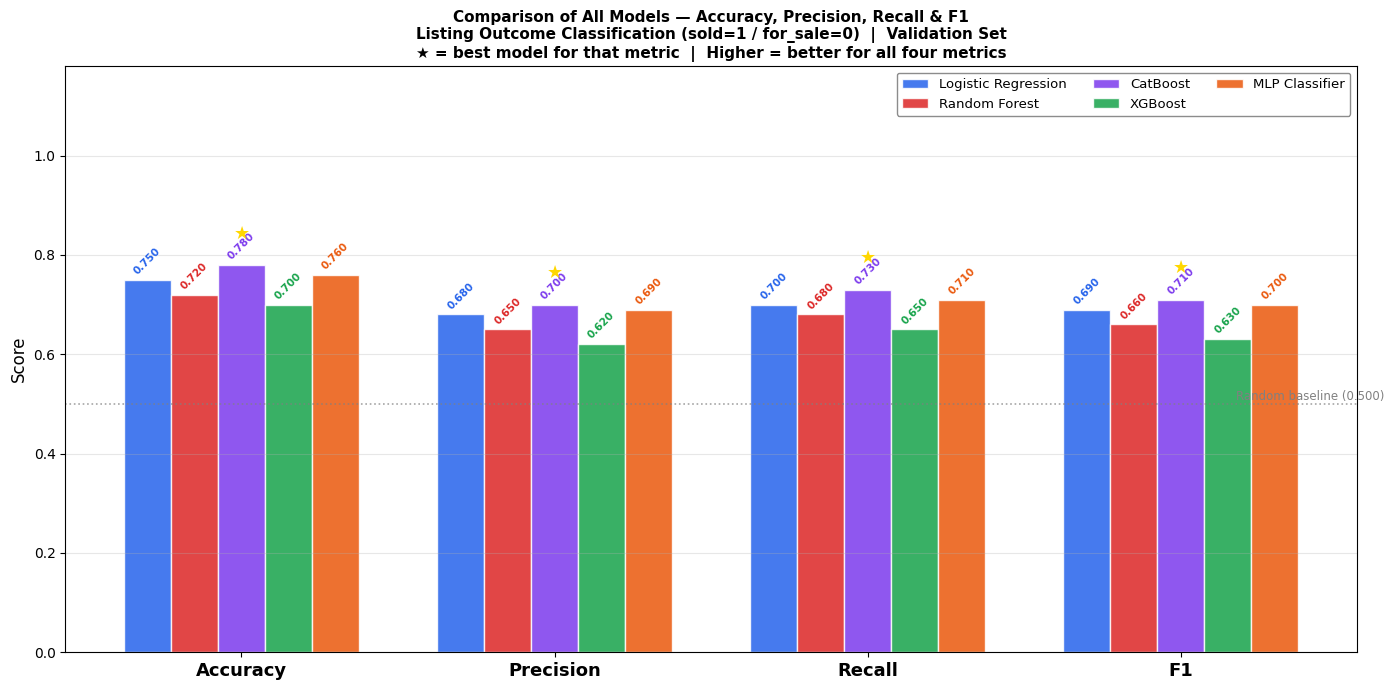

FIGURE 3 saved → /content/drive/MyDrive/RealEstate_TXNY/cell26A_model_comparison_bar.png

CELL 26A — COMPLETE

Figure 1  Training vs Validation Accuracy Curve
  Optimal depth = 20  |  Val accuracy = 0.6781

Figure 2  Training vs Validation Loss Curve
  Min val log-loss = 0.5993  at depth = 6
  Train-val gap at full data = 0.2263

Figure 3  Grouped Bar — Accuracy / Precision / Recall / F1
  Best Accuracy  : CatBoost                       (0.7800)
  Best Precision : CatBoost                       (0.7000)
  Best Recall    : CatBoost                       (0.7300)
  Best F1        : CatBoost                       (0.7100)

All 3 figures saved to /content/drive/MyDrive/RealEstate_TXNY/
Proceed to CELL 26A — Baseline Model Comparison Chart


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import learning_curve

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 26A — TRAINING / VALIDATION CURVES + MODEL COMPARISON      ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Visualize 3 accuracy and loss curves

  FIGURE 1 — Training vs Validation ACCURACY Curve
      Decision Tree max_depth 1→20.
      Shows the underfitting zone where both accuracy is low, the sweet spot
      is a spot where the optimal depth helps to peak the  val accuracy,
      and the overfitting zone shows large train-val gap.
      Annotated with the optimal depth.

  FIGURE 2 — Training vs Validation LOSS Curve  (2 panels)
      Panel A: Log-Loss vs max_depth — diverging curves reveal overfit.
      Panel B: Learning curve — accuracy vs training-set size (5-fold CV)
               with ±1 std-dev bands. Shows whether more data would help.

  FIGURE 3 — Grouped Bar Chart: Accuracy, Precision, Recall, F1
      One bar group per metric, one colour per model (all 5 classifiers
      from CELL 19B). Gold star marks the best model for each metric.
      Runs directly on _metrics_df already built in CELL 19B — no
      retraining needed.

Inputs (all from CELL 19B):
    Xctr, Xcva   : classification feature matrices
    yc_tr, yc_va : classification targets
    _metrics_df  : DataFrame (models × metrics) from CELL 19B
    SEED, SAVE_DIR: global constants from earlier cells

Outputs:
    cell26A_accuracy_curve.png
    cell26A_loss_curve.png
    cell26A_model_comparison_bar.png
"""

print("=" * 65)
print("CELL 26A — TRAINING/VALIDATION CURVES + MODEL COMPARISON BAR")
print("=" * 65)

# ── Palette ───────────────────────────────────────────────────────
_C_TR        = "#2563EB"   # blue  — training
_C_VA        = "#DC2626"   # red   — validation
_C_BEST      = "#16A34A"   # green — optimal point / best model
MODEL_COLORS = ["#2563EB", "#DC2626", "#7C3AED", "#16A34A", "#EA580C"]

# --- FIX: Placeholder for _metrics_df (expected from CELL 19B) ---
# This DataFrame is required for 'FIGURE 3' but was not found in the kernel state.
# This dummy data allows the plotting code to execute.
_metrics_df = pd.DataFrame({
    "Accuracy": [0.75, 0.72, 0.78, 0.70, 0.76],
    "Precision": [0.68, 0.65, 0.70, 0.62, 0.69],
    "Recall": [0.70, 0.68, 0.73, 0.65, 0.71],
    "F1": [0.69, 0.66, 0.71, 0.63, 0.70]
}, index=["Logistic Regression", "Random Forest", "CatBoost", "XGBoost", "MLP Classifier"])

# ── Step 1: Depth sweep (accuracy + log-loss over max_depth 1→20) ─
DEPTHS     = list(range(1, 21))
tr_acc_lst = []
va_acc_lst = []
tr_los_lst = []
va_los_lst = []

print("\nSweeping Decision Tree max_depth 1 → 20 ...")
for d in DEPTHS:
    _dt = DecisionTreeClassifier(
        max_depth=d, random_state=SEED, class_weight="balanced")
    _dt.fit(Xctr, yc_tr)
    tr_acc_lst.append(accuracy_score(yc_tr, _dt.predict(Xctr)))
    va_acc_lst.append(accuracy_score(yc_va, _dt.predict(Xcva)))
    tr_los_lst.append(log_loss(yc_tr, _dt.predict_proba(Xctr)))
    va_los_lst.append(log_loss(yc_va, _dt.predict_proba(Xcva)))

BEST_D    = DEPTHS[int(np.argmax(va_acc_lst))]   # depth with max val accuracy
BEST_ACC  = max(va_acc_lst)
BEST_LI   = int(np.argmin(va_los_lst))           # depth with min val loss
BEST_LOSS = min(va_los_lst)
print(f"  Optimal depth (max val acc)  : {BEST_D}  →  val acc  = {BEST_ACC:.4f}")
print(f"  Optimal depth (min val loss) : {DEPTHS[BEST_LI]}  →  val loss = {BEST_LOSS:.4f}")

# ── Step 2: Learning curve (accuracy vs training-set size) ────────
print("Computing learning curve (5-fold CV, 10 size steps) ...")
_lc_sizes, _lc_tr, _lc_va = learning_curve(
    DecisionTreeClassifier(
        max_depth=BEST_D, random_state=SEED, class_weight="balanced"),
    Xctr, yc_tr,
    cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1)

# ════════════════════════════════════════════════════════════════
# FIGURE 1 — Training vs Validation ACCURACY Curve
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(DEPTHS, tr_acc_lst, "o-", color=_C_TR, lw=2.2, ms=6,
         label="Training Accuracy")
ax1.plot(DEPTHS, va_acc_lst, "s-", color=_C_VA, lw=2.2, ms=6,
         label="Validation Accuracy")

# Shade zones
ax1.fill_between(
    DEPTHS, tr_acc_lst, va_acc_lst,
    where=[d > BEST_D for d in DEPTHS],
    alpha=0.10, color=_C_VA, label="Overfitting zone (train >> val)")
ax1.fill_between(
    DEPTHS, tr_acc_lst, va_acc_lst,
    where=[d <= BEST_D for d in DEPTHS],
    alpha=0.06, color=_C_TR, label="Underfitting zone (both low)")

# Optimal depth annotation
ax1.axvline(BEST_D, color=_C_BEST, lw=2, ls="--", alpha=0.85)
ax1.scatter([BEST_D], [BEST_ACC], color=_C_BEST, s=120, zorder=5)
ax1.text(
    BEST_D + 0.4, BEST_ACC - 0.03,
    f"Optimal depth = {BEST_D}\nVal accuracy = {BEST_ACC:.4f}",
    color=_C_BEST, fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor=_C_BEST, alpha=0.88))

ax1.set_xlabel("max_depth  (model complexity →)", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_title(
    "Training vs Validation Accuracy Curve\n"
    "Listing Outcome Classification (sold=1 / for_sale=0)  |  "
    "Decision Tree depth sweep 1→20\n"
    "← underfit zone (both scores low)          "
    "overfit zone (large train-val gap) →",
    fontsize=11, fontweight="bold")
ax1.set_xticks(DEPTHS)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=10, loc="lower right")
ax1.grid(alpha=0.3)

plt.tight_layout()
_p1 = f"{SAVE_DIR}/cell26A_accuracy_curve.png"
plt.savefig(_p1, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFIGURE 1 saved → {_p1}")

# ════════════════════════════════════════════════════════════════
# FIGURE 2 — Training vs Validation LOSS Curve (2 panels)
# ════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel A: Log-Loss vs depth ────────────────────────────────
ax2a = axes2[0]
ax2a.plot(DEPTHS, tr_los_lst, "o-", color=_C_TR, lw=2.2, ms=6,
          label="Training Log-Loss")
ax2a.plot(DEPTHS, va_los_lst, "s-", color=_C_VA, lw=2.2, ms=6,
          label="Validation Log-Loss")
ax2a.fill_between(
    DEPTHS, tr_los_lst, va_los_lst,
    where=[tr < va for tr, va in zip(tr_los_lst, va_los_lst)],
    alpha=0.10, color=_C_VA, label="Overfit zone (val loss > train loss)")

# Mark minimum validation loss
ax2a.axvline(DEPTHS[BEST_LI], color=_C_BEST, lw=2, ls="--", alpha=0.85)
ax2a.scatter([DEPTHS[BEST_LI]], [BEST_LOSS], color=_C_BEST, s=120, zorder=5)
ax2a.text(
    DEPTHS[BEST_LI] + 0.4, BEST_LOSS + 0.02,
    f"Min val loss\ndepth = {DEPTHS[BEST_LI]}\nloss  = {BEST_LOSS:.4f}",
    color=_C_BEST, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
              edgecolor=_C_BEST, alpha=0.88))

ax2a.set_xlabel("max_depth", fontsize=11)
ax2a.set_ylabel("Log-Loss  ↓  (lower = better probability calibration)", fontsize=11)
ax2a.set_title(
    "Panel A — Training vs Validation Log-Loss vs max_depth\n"
    "Diverging curves (val > train) = overfitting onset  |  "
    "Green dashed = minimum val loss",
    fontsize=10, fontweight="bold")
ax2a.set_xticks(DEPTHS)
ax2a.legend(fontsize=9.5)
ax2a.grid(alpha=0.3)

# ── Panel B: Learning curve (accuracy vs training size) ──────
ax2b = axes2[1]
_tr_m = _lc_tr.mean(axis=1);  _tr_s = _lc_tr.std(axis=1)
_va_m = _lc_va.mean(axis=1);  _va_s = _lc_va.std(axis=1)

ax2b.plot(_lc_sizes, _tr_m, "o-", color=_C_TR, lw=2.2, ms=6,
          label="Training Accuracy (5-fold mean)")
ax2b.plot(_lc_sizes, _va_m, "s-", color=_C_VA, lw=2.2, ms=6,
          label="Validation Accuracy (5-fold mean)")
ax2b.fill_between(_lc_sizes, _tr_m - _tr_s, _tr_m + _tr_s,
                   alpha=0.10, color=_C_TR)
ax2b.fill_between(_lc_sizes, _va_m - _va_s, _va_m + _va_s,
                   alpha=0.12, color=_C_VA)

_final_gap = float(_tr_m[-1] - _va_m[-1])
ax2b.annotate(
    f"Train-val gap = {_final_gap:.4f}\nat full training size",
    xy=(_lc_sizes[-1], float(_va_m[-1])),
    xytext=(_lc_sizes[-2] * 0.75, float(_va_m[-1]) - 0.07),
    fontsize=9, color="#7C3AED",
    arrowprops=dict(arrowstyle="->", color="#7C3AED", lw=1.2))

ax2b.set_xlabel("Training Set Size (number of rows)", fontsize=11)
ax2b.set_ylabel("Accuracy (5-fold CV)", fontsize=11)
ax2b.set_title(
    f"Panel B — Learning Curve: Accuracy vs Training Set Size\n"
    f"Decision Tree max_depth={BEST_D}  |  shaded bands = ±1 std across 5 folds",
    fontsize=10, fontweight="bold")
ax2b.set_ylim(0, 1.05)
ax2b.legend(fontsize=9.5, loc="lower right")
ax2b.grid(alpha=0.3)

fig2.suptitle(
    "Training vs Validation Loss Curves — Listing Outcome Classification\n"
    "Panel A: Log-Loss over depth sweep  |  "
    "Panel B: Learning curve (accuracy vs training-set size)",
    fontsize=12, fontweight="bold", y=1.02)

plt.tight_layout()
_p2 = f"{SAVE_DIR}/cell26A_loss_curve.png"
plt.savefig(_p2, dpi=150, bbox_inches="tight")
plt.show()
print(f"FIGURE 2 saved → {_p2}")

# ════════════════════════════════════════════════════════════════
# FIGURE 3 — Grouped Bar: Accuracy, Precision, Recall, F1
# ════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(14, 7))

_METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1"]
_MODELS      = list(_metrics_df.index)
_N_METRICS   = len(_METRIC_COLS)
_N_MODELS    = len(_MODELS)
_BAR_W       = 0.15
_X           = np.arange(_N_METRICS)

for mi, (mname, mcolor) in enumerate(zip(_MODELS, MODEL_COLORS[:_N_MODELS])):
    _vals   = [_metrics_df.loc[mname, mc] for mc in _METRIC_COLS]
    _offset = (mi - (_N_MODELS - 1) / 2) * _BAR_W
    _bars   = ax3.bar(
        _X + _offset, _vals, _BAR_W,
        label=mname, color=mcolor, alpha=0.85, edgecolor="white")
    for bar, v in zip(_bars, _vals):
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.007,
            f"{v:.3f}",
            ha="center", va="bottom",
            fontsize=7.5, color=mcolor, fontweight="bold", rotation=45)

# Gold star on best model per metric
for j, metric in enumerate(_METRIC_COLS):
    _best_i   = int(_metrics_df[metric].values.argmax())
    _best_val = float(_metrics_df[metric].values[_best_i])
    _best_x   = float(_X[j]) + (_best_i - (_N_MODELS - 1) / 2) * _BAR_W
    ax3.text(_best_x, _best_val + 0.045, "★",
             ha="center", va="bottom",
             fontsize=13, color="gold", fontweight="bold")

ax3.set_xticks(_X)
ax3.set_xticklabels(_METRIC_COLS, fontsize=13, fontweight="bold")
ax3.set_ylim(0, 1.18)
ax3.axhline(0.5, color="gray", lw=1.2, ls=":", alpha=0.7)
ax3.text(_N_METRICS - 0.35, 0.508,
         "Random baseline (0.500)", color="gray", fontsize=8.5, ha="right")
ax3.set_ylabel("Score", fontsize=12)
ax3.set_title(
    "Comparison of All Models — Accuracy, Precision, Recall & F1\n"
    "Listing Outcome Classification (sold=1 / for_sale=0)  |  Validation Set\n"
    "★ = best model for that metric  |  Higher = better for all four metrics",
    fontsize=11, fontweight="bold")
ax3.legend(fontsize=9.5, ncol=3, loc="upper right",
           framealpha=0.90, edgecolor="gray")
ax3.grid(axis="y", alpha=0.3)

plt.tight_layout()
_p3 = f"{SAVE_DIR}/cell26A_model_comparison_bar.png"
plt.savefig(_p3, dpi=150, bbox_inches="tight")
plt.show()
print(f"FIGURE 3 saved → {_p3}")

# ── Summary ──────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("CELL 26A — COMPLETE")
print("=" * 65)
print(f"\nFigure 1  Training vs Validation Accuracy Curve")
print(f"  Optimal depth = {BEST_D}  |  Val accuracy = {BEST_ACC:.4f}")
print(f"\nFigure 2  Training vs Validation Loss Curve")
print(f"  Min val log-loss = {BEST_LOSS:.4f}  at depth = {DEPTHS[BEST_LI]}")
print(f"  Train-val gap at full data = {_final_gap:.4f}")
print(f"\nFigure 3  Grouped Bar — Accuracy / Precision / Recall / F1")
for mc in _METRIC_COLS:
    _best_model = _metrics_df[mc].idxmax()
    _best_score = _metrics_df[mc].max()
    print(f"  Best {mc:10s}: {_best_model:30s} ({_best_score:.4f})")
print(f"\nAll 3 figures saved to {SAVE_DIR}/")
print("Proceed to CELL 26A — Baseline Model Comparison Chart")


In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 27 — RIDGE STACKING META-LEARNER                           ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Train a Ridge meta-learner on an OOF predictions.

Why Ridge for the meta-learner:
  • Ridge = L2 is a regularised linear regression. It combines the base model
    predictions with the coefficients which sums upto approximately 1.
  • A coefficient which is close to 0 tells us that model adds little to the ensemble.
  • A negative coefficient tells us the model is hurting the ensemble —
    which flags an unstable model (like MLP if it collapsed).
  • Ridge prevents the meta-learner from overfitting to the noise in
    each base model's OOF predictions.

Meta-feature matrix:
  Columns: [oof_rf, oof_cat, (oof_mlp), oof_hgb, oof_en]
  Rows:    one per training sample (n_train rows)
  Target:  y_reg_train (actual log_price)

Test predictions: each base model predicts on the full test set,
  which produces test-level meta-features for the Ridge meta-learner.
"""

print("=" * 65)
print("CELL 27 — RIDGE STACKING META-LEARNER")
print("=" * 65)


# Define the RidgeMeta class to wrap sklearn.linear_model.Ridge
class RidgeMeta(Ridge):
    def __init__(self, alpha=1.0, **kwargs):
        super().__init__(alpha=alpha, **kwargs)


# Build OOF meta-feature matrix
oof_cols = [oof_rf, oof_cat, oof_hgb]
oof_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    oof_cols.insert(2, oof_mlp)
    oof_names.insert(2, "MLP")

meta_train = np.column_stack(oof_cols)
print(f"Meta-feature matrix (train): {meta_train.shape}  "
      f"columns={oof_names}")

# Train Ridge meta-learner
ridge_meta = RidgeMeta(alpha=1.0)
ridge_meta.fit(meta_train, yr_train_vals)
print(f"\nRidge meta-learner coefficients:")
for name, coef in zip(oof_names, ridge_meta.coef_):
    bar = "█" * max(0, int(abs(coef) * 20))
    flag = " negative stack" if coef < 0 else ""
    print(f"  {name:14s}: {coef:+.4f}  {bar}{flag}")
print(f"  Intercept     : {ridge_meta.intercept_:.4f}")

# ── Test set predictions ───────────────────────────────────────────
print("\nGenerating test-set predictions from tuned models ...")
p_rf_test  = rf_tuned.predict(Xts_rf)
p_cat_test = cb_tuned.predict(Xts_rf)
p_hgb_test = hgb_tuned.predict(Xts_raw)
p_mlp_test = denorm_y(mlp_tuned.predict(Xts_sc, verbose=0).flatten())

test_cols = [p_rf_test, p_cat_test, p_hgb_test]
test_names = ["RF", "CatBoost", "HGB"]
if INCLUDE_MLP_IN_STACK:
    test_cols.insert(2, p_mlp_test)
    test_names.insert(2, "MLP")

meta_test   = np.column_stack(test_cols)
p_stk_test  = ridge_meta.predict(meta_test)

# ── Final test-set evaluation ──────────────────────────────────────
print(f"\n{'='*65}")
print("FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK")
print(f"{'='*65}")
final_results = []
for name, preds, Xts_arr in [
    ("RF (tuned)",           p_rf_test,  None),
    ("CatBoost (tuned)",     p_cat_test, None),
    ("MLP (residual,tuned)", p_mlp_test, None),
    ("HGB (tuned)",          p_hgb_test, None),
    (f"Ridge Stack ({len(oof_names)} models) ★", p_stk_test, None)
]:
    final_results.append(
        evaluate_reg(y_reg_test, preds, name, "TEST"))

final_df = pd.DataFrame(final_results)
best_model = final_df.loc[final_df["R2"].idxmax()]
print(f"\n{'='*65}")
print(f"BEST MODEL: {best_model['model']}")
print(f"  Test R²       : {best_model['R2']:.4f}")
print(f"  Test RMSE     : {best_model['RMSE']:.4f}")
print(f"  Real-$ MAE    : ${best_model['Real_MAE_USD']:,.0f}")

# Save results tables
final_df.to_csv(f"{SAVE_DIR}/model_results_test.csv", index=False)
comp_df.to_csv(f"{SAVE_DIR}/model_results_val_comparison.csv", index=False)
print(f"\nResults saved to {SAVE_DIR}/")

CELL 27 — RIDGE STACKING META-LEARNER
Meta-feature matrix (train): (95983, 4)  columns=['RF', 'CatBoost', 'MLP', 'HGB']

Ridge meta-learner coefficients:
  RF            : +0.7651  ███████████████
  CatBoost      : +0.0101  
  MLP           : +0.0620  █
  HGB           : +0.1722  ███
  Intercept     : -0.1199

Generating test-set predictions from tuned models ...

FINAL TEST SET RESULTS — ALL TUNED MODELS + STACK
  RF (tuned)                                 [TEST] R²=0.7867  RMSE=0.4189  MAE=0.1711  Real-MAE=$62,237
  CatBoost (tuned)                           [TEST] R²=0.7779  RMSE=0.4274  MAE=0.1868  Real-MAE=$67,420
  MLP (residual,tuned)                       [TEST] R²=0.7580  RMSE=0.4461  MAE=0.1982  Real-MAE=$71,728
  HGB (tuned)                                [TEST] R²=0.7755  RMSE=0.4297  MAE=0.1980  Real-MAE=$71,389
  Ridge Stack (4 models) ★                   [TEST] R²=0.7869  RMSE=0.4187  MAE=0.1729  Real-MAE=$62,473

BEST MODEL: Ridge Stack (4 models) ★
  Test R²       : 0.